# Fig.1 Pipeline
使用模型对两张图像分别嵌入水印，再按 mask 合成，最后解码并可视化 `color_bit_active`。

In [6]:
import os

import sys
import time
import importlib
import random

import numpy as np
import torch
import torch.nn.functional as F
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image


from watermark_anything.data.transforms import (
    get_transforms_segmentation,
    unnormalize_img,
)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
print(f"device: {device}")

device: cuda


## Configuration

In [7]:
from types import SimpleNamespace

args = SimpleNamespace(
    image_size          = 256,
    fig1_dir            = "assets/fig_1",       # contains 000000235857.jpg / 000000237864.jpg / 000000235857_mask.png
    fig1_paste_shift_y  = 0,
    color_overlay_alpha = 0.5,
)

# Fix random seed
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

## Import Helper Functions

In [8]:
from color_utils import recolor_bit_active_blue_light_red

## Fig.1 Composite & Decode

## Initialize Model

In [9]:
from val_sun import Watermark_model

watermark_model = Watermark_model(device=device)
print("Model loaded")

Loading model... DenseMark ================================
used model is checkpoints/bce_bg_crl_llr.pth
making attention of type 'vanilla' with 128 in_channels
Working with z of shape (1, 100, 16, 16) = 25600 dimensions.
making attention of type 'vanilla' with 128 in_channels


Model loaded successfully from /data1/jiaxin1/ajiaxin/1jxcode/public_code/DenseMark/checkpoints/bce_bg_crl_llr.pth
{'embedder_config': 'configs/embedder.yaml', 'augmentation_config': 'configs/all_augs_multi_wm.yaml', 'extractor_config': 'configs/extractor.yaml', 'attenuation_config': 'configs/attenuation.yaml', 'embedder_model': 'vae_big16', 'extractor_model': 'sam_large', 'nbits': 48, 'img_size': 256, 'img_size_extractor': 256, 'attenuation': 'jnd_1_3_blue', 'scaling_w': 1.0, 'scaling_w_schedule': None, 'scaling_i': 1.0, 'roll_probability': 0.2, 'multiple_w': 1.0, 'nb_wm_eval': 5, 'optimizer': 'AdamW,lr=1e-4', 'optimizer_d': None, 'scheduler': 'CosineLRScheduler,lr_min=1e-6,t_initial=100,warmup_lr_init=1e-6,warmup_t=5', 'epochs': 200, 'batch_size': 8, 'batch_size_eval': 64, 'temperature': 1.0, 'workers': 40, 'to_freeze_embedder': None, 'lambda_w': 1.0, 'lambda_w2': 6.0, 'lambda_i': 0.0, 'lambda_d': 0.0, 'balanced': True, 'total_gnorm': 0.0, 'perceptual_loss': 'none', 'disc_start': 0, 

## Run Pipeline

[mult_bit] bit_acc vs msg1: 1.000 | msg2: 1.000


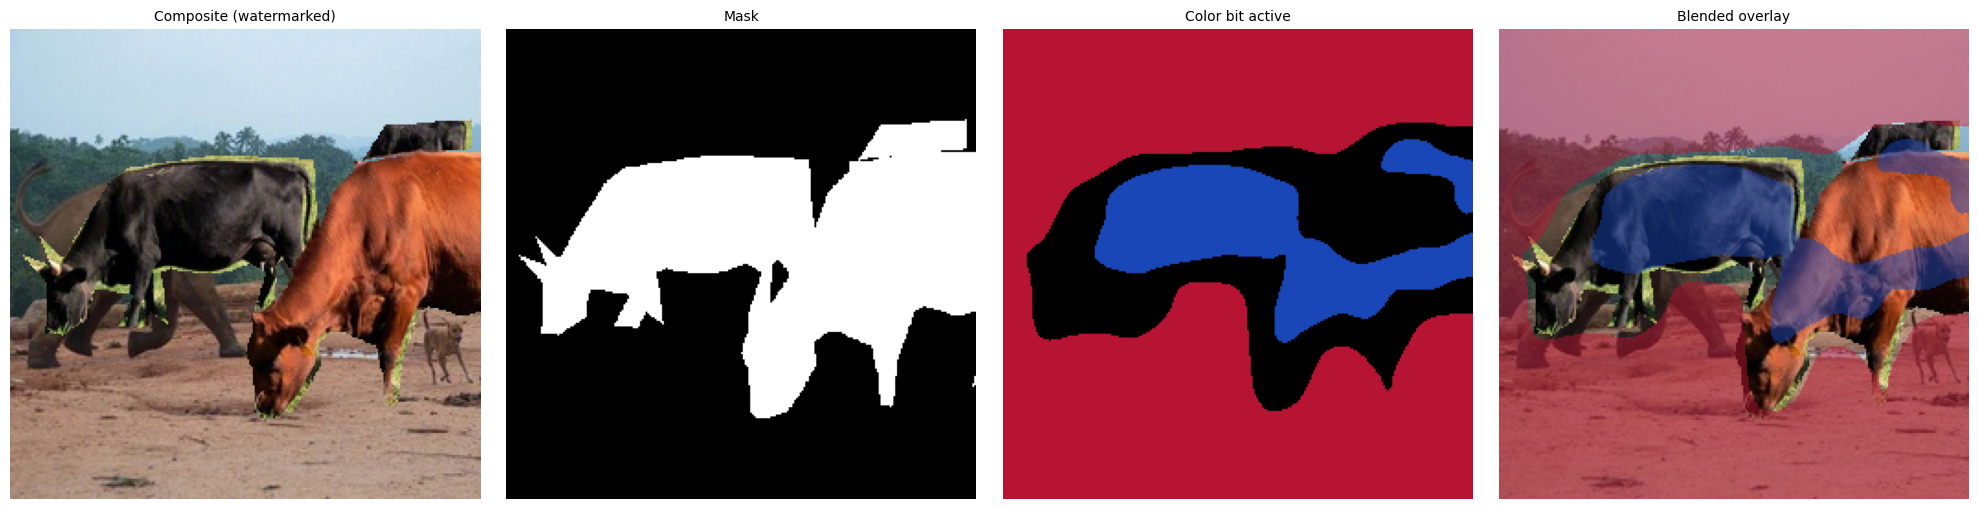

In [11]:
import matplotlib.pyplot as plt

_, _, val_transform, val_mask_transform = get_transforms_segmentation(args.image_size)

# ── Load images ────────────────────────────────────────────────────
fig1_dir = args.fig1_dir if os.path.isabs(args.fig1_dir) else os.path.join(BASE_DIR, args.fig1_dir)
p1 = os.path.join(fig1_dir, "000000235857.jpg")
p2 = os.path.join(fig1_dir, "000000237864.jpg")
pm = os.path.join(fig1_dir, "000000235857_mask.png")
for p in (p1, p2, pm):
    if not os.path.isfile(p):
        raise FileNotFoundError(f"Missing file: {p}")

pil1  = Image.open(p1).convert("RGB")
pil2  = Image.open(p2).convert("RGB")
pil_m = val_mask_transform(Image.open(pm).convert("L"))

img1  = val_transform(pil1).unsqueeze(0).to(device)
img2  = val_transform(pil2).unsqueeze(0).to(device)
mask1 = (T.ToTensor()(pil_m) > 0.5).float().unsqueeze(0).to(device)
if mask1.shape[-2:] != img1.shape[-2:]:
    mask1 = F.interpolate(mask1, size=img1.shape[-2:], mode="nearest")

# ── Encode ─────────────────────────────────────────────────────────
out1 = watermark_model.encode(img1)
out2 = watermark_model.encode(img2)
enc1, msg1 = out1["images_encoded"], out1["msgs_encoded"]   # [1, 32]
enc2, msg2 = out2["images_encoded"], out2["msgs_encoded"]   # [1, 32]

# ── Composite ──────────────────────────────────────────────────────
composite = enc1 * mask1 + enc2 * (1.0 - mask1)

# ── Decode ─────────────────────────────────────────────────────────
output_decode = watermark_model.decode(composite)

msgs_decoded     = output_decode["msgs_decoded"]          # [1, 32]
mult_bit         = output_decode["mult_bit"]              # (vectors_list, counts_list)
color_bit_active = output_decode.get("color_bit_active")  # [1, 3, H, W] or None

# ── mult_bit：用候选集合做“max pooling”版本 bit_acc ───────────────────

wm_msgs = torch.cat([msg1, msg2], dim=0)   # [2, 32]
candidates = mult_bit[0]                  # [N, 32]

if candidates.shape[0] == 0:
    print("[mult_bit] No valid candidate vectors detected")
    acc1 = acc2 = 0.0
else:
    # [N, 32] vs [2, 32] → [2, N, 32]
    match = (candidates.unsqueeze(0) == wm_msgs.unsqueeze(1)).float()
    best_match_per_bit = match.max(dim=1).values
    acc1, acc2 = best_match_per_bit.mean(dim=1).tolist()
    acc1, acc2 = round(acc1, 3), round(acc2, 3)

print(f"[mult_bit] bit_acc vs msg1: {acc1:.3f} | msg2: {acc2:.3f}")

base = unnormalize_img(composite).clamp(0, 1)
if color_bit_active is not None:
    cba = color_bit_active.clone()
    if cba.shape[-2:] != base.shape[-2:]:
        cba = F.interpolate(cba, size=base.shape[-2:], mode="bilinear", align_corners=False)
    cba     = recolor_bit_active_blue_light_red(cba.clamp(0, 1))
    active  = (cba.sum(dim=1, keepdim=True) > 1e-4).float()
    alpha   = max(0.0, min(1.0, float(args.color_overlay_alpha)))
    blended = (base * (1.0 - alpha * active) + cba * alpha * active).clamp(0, 1)
    panels  = [
        ("Composite (watermarked)", base),
        ("Mask",                    mask1.repeat(1, 3, 1, 1)),
        ("Color bit active",        cba),
        ("Blended overlay",         blended),
    ]
else:
    panels = [
        ("Composite (watermarked)", base),
        ("Mask",                    mask1.repeat(1, 3, 1, 1)),
    ]
    print("[fig_1] decode did not return color_bit_active, skipping color overlay.")

fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 5))
for ax, (title, t) in zip(axes, panels):
    ax.imshow(t[0].permute(1, 2, 0).detach().cpu().numpy().clip(0, 1))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()